# Neural Networks 83695 — Final Project, Part C

**Submitted by:** Noam Major (ID 208941989), Ziv Assoulin (ID 325312999)

In this part we train classifiers to separate **spiny** from **aspiny** neurons using
the electrophysiological feature table (`feat_data.csv`). The `dendrite_type` column is
used only as the label and is never used as an input feature to any of the models.

**spiny is the positive class** for every precision / recall / F1 figure reported below.

Sections covered: **1a, 2a, 2b, 3a, 3b, 3c, 4a, 4b, 4c, 4d, 4e**.

## Setup

Every source of randomness in this project — the train/test split, the sklearn solvers,
and the torch weight initialization and dropout masks — is derived from a single seed, so
re-running the notebook reproduces exactly the numbers reported in the analysis.

In [1]:

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay)

%matplotlib inline
# Reset to matplotlib's default (white) style and pin a white background: a dark IDE
# theme (e.g. PyCharm's) otherwise renders the figures on a black background.
plt.style.use('default')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'savefig.facecolor': 'white', 'savefig.transparent': False})
plt.rcParams['figure.figsize'] = (6, 5)

SEED = 42


def set_seed(seed=SEED):
    """Reseed python, numpy and torch. Call before building/training a torch model:
    weight init draws from the global torch RNG, so without this each model in a loop
    starts from a different initialization and the comparison is not reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

## Loading the data and splitting train/test

A random 80% train / 20% test split. We pass `stratify=y` so the spiny/aspiny ratio is
identical in both sets — without it an unlucky draw could skew the test metrics.

In [2]:
import os

# On Colab the runtime starts empty: upload feat_data.csv when prompted.
# Locally the file sits next to the notebook and this block is skipped.
if not os.path.exists('feat_data.csv'):
    from google.colab import files
    files.upload()


def load_data():
    df = pd.read_csv('feat_data.csv')

    y = df['dendrite_type']                    # label
    X = df.drop(columns=['dendrite_type'])     # never used as a feature

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    return X_train, X_test, y_train, y_test


LABELS = {'aspiny': 0, 'spiny': 1}


def to_tensors(X_train, X_test, y_train, y_test):
    """Standardize (fit on train only) and convert the pandas frames to torch tensors.

    CrossEntropyLoss wants float inputs and int64 class indices, and the string labels
    have to be mapped to 0/1 first.
    """
    scaler = StandardScaler().fit(X_train)
    return (torch.tensor(scaler.transform(X_train), dtype=torch.float32),
            torch.tensor(y_train.map(LABELS).values, dtype=torch.long),
            torch.tensor(scaler.transform(X_test), dtype=torch.float32),
            torch.tensor(y_test.map(LABELS).values, dtype=torch.long))


X_train, X_test, y_train, y_test = load_data()
print(f'train: {X_train.shape[0]} samples, test: {X_test.shape[0]} samples, '
      f'{X_train.shape[1]} features')
print('train class counts:', y_train.value_counts().to_dict())
print('test  class counts:', y_test.value_counts().to_dict())

train: 1139 samples, test: 285 samples, 41 features
train class counts: {'aspiny': 579, 'spiny': 560}
test  class counts: {'aspiny': 145, 'spiny': 140}


## Question 1 — Logistic regression

### 1a — Error analysis

We fit a logistic regression on the training set and evaluate on the test set. The
`StandardScaler` sits **inside** the pipeline, so its mean and standard deviation are
learned from the training fold only and merely *applied* to the test fold. Fitting the
scaler on the full dataset would leak test statistics into training.

Reported below: the confusion matrix, plus precision and recall with spiny as the
positive class.

logistic regression: accuracy=0.9860, precision=0.9928, recall=0.9786, f1=0.9856
  true negatives  (aspiny -> aspiny): 144
  false positives (aspiny -> spiny) : 1
  false negatives (spiny  -> aspiny): 3
  true positives  (spiny  -> spiny) : 137


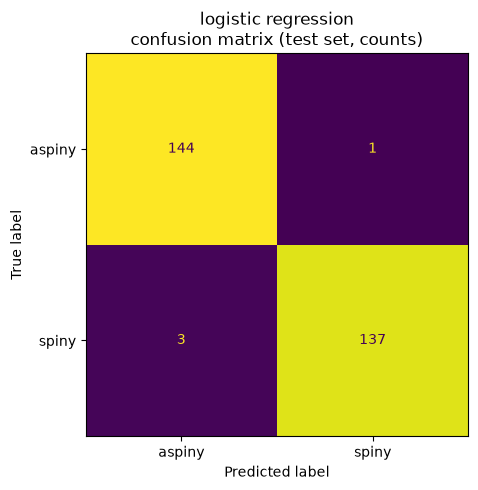

In [3]:
def make_log_reg():
    """Logistic regression on standardized features.

    The StandardScaler lives inside the pipeline so its mean/std are learned from the
    training fold only and merely applied to the test fold -- fitting the scaler on the
    full dataset would leak test statistics into training.
    """
    return make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=1000, random_state=SEED))


def report_errors(y_true, y_pred, title):
    """Confusion matrix + the metrics of Q1a, with `spiny` as the positive class."""
    cm = confusion_matrix(y_true, y_pred, labels=['aspiny', 'spiny'])
    (tn, fp), (fn, tp) = cm

    metrics = (accuracy_score(y_true, y_pred),
               precision_score(y_true, y_pred, pos_label='spiny'),
               recall_score(y_true, y_pred, pos_label='spiny'),
               f1_score(y_true, y_pred, pos_label='spiny'))
    print(f'{title}: accuracy={metrics[0]:.4f}, precision={metrics[1]:.4f}, '
          f'recall={metrics[2]:.4f}, f1={metrics[3]:.4f}')
    # Break the errors out by direction: precision and recall summarize them, but the
    # counts say which mistake the model actually makes.
    print(f'  true negatives  (aspiny -> aspiny): {tn}')
    print(f'  false positives (aspiny -> spiny) : {fp}')
    print(f'  false negatives (spiny  -> aspiny): {fn}')
    print(f'  true positives  (spiny  -> spiny) : {tp}')

    disp = ConfusionMatrixDisplay(cm, display_labels=['aspiny', 'spiny'])
    disp.plot(colorbar=False)
    disp.ax_.set_title(f'{title}\nconfusion matrix (test set, counts)')
    plt.tight_layout()
    plt.show()
    return metrics


def train_log_r(X_train, X_test, y_train, y_test):
    log_reg = make_log_reg()
    log_reg.fit(X_train, y_train)  # learns mean/std + weights: z = xw + b -> sigmoid(z)
    y_pred = log_reg.predict(X_test)
    metrics = report_errors(y_test, y_pred, 'logistic regression')
    return log_reg, metrics


log_reg, log_reg_metrics = train_log_r(X_train, X_test, y_train, y_test)

### Findings — 1a

The model makes 4 errors out of 285 samples (accuracy 0.9860), but they are not
symmetric:

* **3 false negatives** — spiny neurons classified as aspiny
* **1 false positive** — an aspiny neuron classified as spiny

This is why recall (0.9786) sits below precision (0.9928): the model is somewhat
*conservative* about assigning the spiny label. Almost everything it calls spiny really
is spiny, but it misses a few genuine spiny neurons. Biologically, this says a small
subset of spiny neurons carries electrical features close enough to the aspiny profile
to fall on the wrong side of the decision boundary.

## Question 2 — Perceptron

We train a perceptron on the same training set and evaluate on the same test set.
Structurally it is the same model as the logistic regression — a linear classifier over
the same standardized features — but with no sigmoid, so it has no probabilistic output
and updates its weights only on misclassified samples.

The logistic regression fitted in Question 1 is passed in rather than refitted, so both
sections report the same model.

In [4]:
METRIC_NAMES = ('accuracy', 'precision', 'recall', 'f1')


def compare_models(results, names, split='test'):
    """Q2a: which model generalized better, judged on the held-out split.

    Generalization is measured on data neither model was fitted to, so the comparison is
    made on `test`; ties are reported as such rather than broken arbitrarily.
    """
    header = f"{'metric':10s}" + ''.join(f'{n:>13s}' for n in names) + f"{'better':>14s}"
    print(header)
    print('-' * len(header))
    wins = {name: 0 for name in names}
    for i, metric in enumerate(METRIC_NAMES):
        values = [results[(name, split)][i] for name in names]
        best = max(values)
        leaders = [n for n, v in zip(names, values) if v == best]
        verdict = 'tie' if len(leaders) > 1 else leaders[0]
        if len(leaders) == 1:
            wins[leaders[0]] += 1
        print(f'{metric:10s}' + ''.join(f'{v:13.4f}' for v in values) + f'{verdict:>14s}')
    ranked = sorted(wins.items(), key=lambda kv: kv[1], reverse=True)
    print(f'-> {ranked[0][0]} generalizes better '
          f'({ranked[0][1]} of {len(METRIC_NAMES)} metrics on {split})')


def report_overfitting(results, names):
    """Q2b: train-test gap for each model in `results`, keyed by (name, split).

    A large positive gap (train well above test) is the signature of overfitting: the
    model has memorized the training set instead of learning a rule that transfers. A gap
    near zero -- or negative, where test happens to score higher -- means it has not.
    """
    header = f"{'model':12s} {'metric':10s} {'train':>8s} {'test':>8s} {'gap':>8s}"
    print(header)
    print('-' * len(header))
    for name in names:
        train, test = results[(name, 'train')], results[(name, 'test')]
        for metric, tr, te in zip(METRIC_NAMES, train, test):
            print(f'{name:12s} {metric:10s} {tr:8.4f} {te:8.4f} {tr - te:+8.4f}')


def com_log_per(X_train, X_test, y_train, y_test, log_reg=None):
    perc = make_pipeline(StandardScaler(), Perceptron(max_iter=1000, random_state=SEED)) #same as log_reg, just without sigmoid, put sign(z)
    perc.fit(X_train, y_train)
    if log_reg is None:  # reuse the model fitted in Q1 so both sections report one model
        log_reg = make_log_reg().fit(X_train, y_train)
    results = {}
    for name, model in [('logreg', log_reg), ('perceptron', perc)]:
        for split, X, y in [('train', X_train, y_train), ('test', X_test, y_test)]:
            yp = model.predict(X)
            # Key on (model, split): keying on `name` alone let the test row overwrite the
            # train row, discarding the train metrics that Q2b needs for the overfitting gap.
            results[(name, split)] = (accuracy_score(y, yp),
                                      precision_score(y, yp, pos_label='spiny'),
                                      recall_score(y, yp, pos_label='spiny'),
                                      f1_score(y, yp, pos_label='spiny'))
    compare_models(results, ['logreg', 'perceptron'])
    print()
    report_overfitting(results, ['logreg', 'perceptron'])
    return results


baseline_results = com_log_per(X_train, X_test, y_train, y_test, log_reg=log_reg)

metric           logreg   perceptron        better
--------------------------------------------------
accuracy         0.9860       0.9614        logreg
precision        0.9928       0.9448        logreg
recall           0.9786       0.9786           tie
f1               0.9856       0.9614        logreg
-> logreg generalizes better (3 of 4 metrics on test)

model        metric        train     test      gap
--------------------------------------------------
logreg       accuracy     0.9824   0.9860  -0.0035
logreg       precision    0.9839   0.9928  -0.0089
logreg       recall       0.9804   0.9786  +0.0018
logreg       f1           0.9821   0.9856  -0.0035
perceptron   accuracy     0.9675   0.9614  +0.0061
perceptron   precision    0.9763   0.9448  +0.0315
perceptron   recall       0.9571   0.9786  -0.0214
perceptron   f1           0.9666   0.9614  +0.0052


### 2a — Which model generalized better?

**Logistic regression generalizes better.** On the test set it wins on accuracy
(0.9860 vs 0.9614) and precision (0.9928 vs 0.9448), and ties the perceptron on recall
(0.9786 — both models correctly identify 137 of the 140 spiny neurons).

So the entire difference between them is **false positives**: the perceptron finds
exactly as many true spiny neurons, but wrongly labels more aspiny neurons as spiny.
The reason is that the perceptron stops updating as soon as a sample is classified
correctly — it maximizes neither a margin nor a likelihood — so its decision boundary is
determined by whichever samples it happened to get wrong last, and is less stable than
the logistic regression's.

### 2b — Do the models overfit?

**No.** The train/test gap is small for both:

| model | train accuracy | test accuracy | gap |
|---|---|---|---|
| logreg | 0.9824 | 0.9860 | **-0.0035** |
| perceptron | 0.9675 | 0.9614 | **+0.0061** |

Logistic regression actually scores *higher* on test than on train (a negative gap),
which rules out memorization of the training set entirely. The perceptron's gap of
0.0061 is fewer than two samples out of 285 — within statistical noise.

One detail worth noting: for the perceptron the precision gap is +0.0315 while the
recall gap is -0.0214, i.e. they point in **opposite directions**. That is not an
overfitting signature but a shift in the decision boundary: on the test set the model is
more generous with the spiny label, so it catches more spiny neurons (recall up) at the
cost of more false positives (precision down).

## Question 3 — MLP

### 3a — Comparing two architectures

We compare two MLP architectures that differ along three axes at once — depth,
activation function, and regularization:

* `mlp` — 1 hidden layer, ReLU, no regularization (the smaller baseline)
* `mlp_dropout` — 2 hidden layers, GELU, dropout 0.2 (deeper and regularized)

Features are standardized before training (the same `StandardScaler` learned from the
training set only), and the neuron-type column is never used as an input. For each
architecture we report the parameter count, activation functions, optimizer, learning
rate, number of epochs, and batch size.

In [5]:
def make_mlp(n_features):
    """The two architectures compared in Q3a.

    Deliberately different on three axes at once (depth, activation, regularization) so
    the comparison is between two genuinely distinct designs:
      mlp         -- 1 hidden layer, ReLU, no regularization  (the smaller baseline)
      mlp_dropout -- 2 hidden layers, GELU, dropout 0.2       (deeper + regularized)
    """
    return nn.Sequential(
        nn.Linear(n_features, 32),
        nn.ReLU(),
        nn.Linear(32, 2)
    ), nn.Sequential(
        nn.Linear(n_features, 32),
        nn.GELU(),
        nn.Dropout(0.2),
        nn.Linear(32, 32),
        nn.GELU(),
        nn.Dropout(0.2),
        nn.Linear(32, 2)
    )


MLP_LR = 0.001


MLP_EPOCHS = 100


MLP_BATCH = 32


def describe_model(name, model, optimizer='Adam', lr=MLP_LR, epochs=MLP_EPOCHS,
                   batch_size=MLP_BATCH):
    """Q3a: report the six required properties of an architecture.

    Parameter count is the trainable-tensor total (weights + biases); the activation list
    is read off the module itself so it cannot drift from the model actually trained.
    """
    linears = [m for m in model if isinstance(m, nn.Linear)]
    widths = ' -> '.join([str(linears[0].in_features)]
                         + [str(layer.out_features) for layer in linears])
    activations = [type(m).__name__ for m in model if not isinstance(m, nn.Linear)]
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f'{name}')
    print(f'  layers        : {widths}')
    print(f'  activations   : {", ".join(activations) or "none"}')
    print(f'  parameters    : {n_params}')
    print(f'  optimizer     : {optimizer}')
    print(f'  learning rate : {lr}')
    print(f'  epochs        : {epochs}')
    print(f'  batch size    : {batch_size}')


def train_torch(model, X_t, y_t, lr=MLP_LR, epochs=MLP_EPOCHS, batch_size=MLP_BATCH):
    """Mini-batch Adam training. Returns the per-epoch mean training loss.

    Each epoch reshuffles the training set; the per-batch loss is weighted by the batch
    size so a smaller trailing batch does not skew the epoch average.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    n_train = X_t.shape[0]

    losses = []
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(n_train)
        epoch_loss = 0.0
        for start in range(0, n_train, batch_size):
            idx = perm[start:start + batch_size]
            optimizer.zero_grad()
            loss = criterion(model(X_t[idx]), y_t[idx])
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(idx)
        losses.append(epoch_loss / n_train)
    return losses


def evaluate_torch(model, X_t, y_t):
    """Accuracy/precision/recall/F1 with spiny (class 1) as the positive class."""
    model.eval()
    with torch.no_grad():
        predicted = model(X_t).argmax(dim=1)
    return (accuracy_score(y_t, predicted),
            precision_score(y_t, predicted, pos_label=1),
            recall_score(y_t, predicted, pos_label=1),
            f1_score(y_t, predicted, pos_label=1))


def comp_2(X_train, X_test, y_train, y_test):
    # The torch models need the same standardization the sklearn pipelines apply internally,
    # otherwise the comparison is unfair (and raw feature scales here span several orders
    # of magnitude, which stalls gradient descent). Scaler is fit on train only.
    X_train_t, y_train_t, X_test_t, y_test_t = to_tensors(X_train, X_test, y_train, y_test)
    n_features = X_train_t.shape[1]
    results = {}
    for i, name in enumerate(['mlp', 'mlp_dropout']):
        set_seed()  # same init draw for both architectures, and stable across reruns
        model = make_mlp(n_features)[i]
        describe_model(name, model)
        train_torch(model, X_train_t, y_train_t)
        # Train metrics as well as test: Q3b compares against the baselines on test, and
        # Q4c needs the train-test gap for the same models.
        results[(name, 'train')] = evaluate_torch(model, X_train_t, y_train_t)
        results[(name, 'test')] = evaluate_torch(model, X_test_t, y_test_t)
        print(f'  test accuracy : {results[(name, "test")][0]:.4f}\n')
    return results


mlp_results = comp_2(X_train, X_test, y_train, y_test)

mlp
  layers        : 41 -> 32 -> 2
  activations   : ReLU
  parameters    : 1410
  optimizer     : Adam
  learning rate : 0.001
  epochs        : 100
  batch size    : 32
  test accuracy : 0.9860

mlp_dropout
  layers        : 41 -> 32 -> 32 -> 2
  activations   : GELU, Dropout, GELU, Dropout
  parameters    : 2466
  optimizer     : Adam
  learning rate : 0.001
  epochs        : 100
  batch size    : 32
  test accuracy : 0.9930



### Findings — 3a

| architecture | layers | activation | parameters | test accuracy |
|---|---|---|---|---|
| `mlp` | 41 → 32 → 2 | ReLU | 1,410 | 0.9860 |
| `mlp_dropout` | 41 → 32 → 32 → 2 | GELU + Dropout(0.2) | 2,466 | 0.9930 |

Both were trained with Adam, learning rate 0.001, 100 epochs, batch size 32.

The deeper regularized architecture wins: 0.9930 vs 0.9860, i.e. two fewer mistakes, at
1.75× the parameters. Both networks reach 1.0000 accuracy on the **training** set — both
fully memorize it — yet `mlp_dropout` generalizes better.

This comparison **cannot say which change caused the improvement.** The two
architectures differ in depth, activation *and* dropout at once, so the 0.7-point gain
belongs to the combination. Isolating a single factor is what 3c does (one
hyper-parameter varied at a time) and what 4d does for dropout specifically.

Note that the train/test gap for both networks (1.0000 vs ~0.99) is larger than the
logistic regression's — an early sign of overfitting, analyzed in detail in 4c.

### 3b — MLP against the two baselines

All four models are evaluated on exactly the same test set, with spiny as the positive
class. `compare_models` prints the metrics side by side, and `report_overfitting` adds
the train/test gap for each model.

In [6]:
all_results = {**baseline_results, **mlp_results}
names = ['logreg', 'perceptron', 'mlp', 'mlp_dropout']
compare_models(all_results, names)
print()
report_overfitting(all_results, names)

metric           logreg   perceptron          mlp  mlp_dropout        better
----------------------------------------------------------------------------
accuracy         0.9860       0.9614       0.9860       0.9930   mlp_dropout
precision        0.9928       0.9448       0.9857       0.9929   mlp_dropout
recall           0.9786       0.9786       0.9857       0.9929   mlp_dropout
f1               0.9856       0.9614       0.9857       0.9929   mlp_dropout
-> mlp_dropout generalizes better (4 of 4 metrics on test)

model        metric        train     test      gap
--------------------------------------------------
logreg       accuracy     0.9824   0.9860  -0.0035
logreg       precision    0.9839   0.9928  -0.0089
logreg       recall       0.9804   0.9786  +0.0018
logreg       f1           0.9821   0.9856  -0.0035
perceptron   accuracy     0.9675   0.9614  +0.0061
perceptron   precision    0.9763   0.9448  +0.0315
perceptron   recall       0.9571   0.9786  -0.0214
perceptron   f1    

### Findings — 3b

| model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| logreg | 0.9860 | 0.9928 | 0.9786 | 0.9856 |
| perceptron | 0.9614 | 0.9448 | 0.9786 | 0.9614 |
| mlp | 0.9860 | 0.9857 | 0.9857 | 0.9857 |
| **mlp_dropout** | **0.9930** | **0.9929** | **0.9929** | **0.9929** |

`mlp_dropout` is best on all four metrics, but keep the size of the win in perspective:
it beats logistic regression by 0.0070 accuracy, which is **two samples** out of 285.
The perceptron is the only model that clearly falls behind.

The substantive conclusion is that this task is close to linearly separable: a simple
linear classifier reaches 98.6%, and a network with 2,466 parameters improves on that by
two samples. The gain from moving to an MLP here is marginal.

The gap table exposes a qualitative difference between the two families: both networks
reach 1.0000 on the training set (gaps of +0.0140 for `mlp` and +0.0070 for
`mlp_dropout`), while logistic regression has a **negative** gap. The networks fully
memorize the training set and the linear models do not — analyzed further in 4c. The
regularized architecture's gap is exactly half the plain one's (+0.0070 vs +0.0140), but
as in 3a this cannot be credited to dropout alone, since the two networks also differ in
depth and activation. 4d isolates dropout on an otherwise identical network.

## 3c — Hyper-parameter sensitivity

We test five hyper-parameters, varying **one at a time** while holding all others fixed
at `BASE_CONFIG`. Sweeping the full cross-product would confound the effects and no
single hyper-parameter's influence could be read off the result.

Scoring is done on a **validation split** of 10% of the training set (114 samples), not
on the test set: choosing hyper-parameters by test accuracy turns the reported test
number into a best-of-N and it stops being an estimate of generalization.

learning rate
     value  accuracy  precision   recall       f1
    0.0001    0.9825     0.9821   0.9821   0.9821
     0.001    0.9912     1.0000   0.9821   0.9910
      0.01    1.0000     1.0000   1.0000   1.0000
       0.1    0.9649     0.9483   0.9821   0.9649
  -> best learning rate: 0.01 (validation accuracy 1.0000)

hidden units per layer
     value  accuracy  precision   recall       f1
         8    0.9912     1.0000   0.9821   0.9910
        16    0.9912     1.0000   0.9821   0.9910
        32    0.9912     1.0000   0.9821   0.9910
        64    0.9912     1.0000   0.9821   0.9910
       128    0.9912     1.0000   0.9821   0.9910
  -> best hidden units per layer: 8 (validation accuracy 0.9912)

hidden layers
     value  accuracy  precision   recall       f1
         1    0.9912     1.0000   0.9821   0.9910
         2    0.9912     1.0000   0.9821   0.9910
         3    1.0000     1.0000   1.0000   1.0000
         4    0.9912     1.0000   0.9821   0.9910
  -> best hidden layers

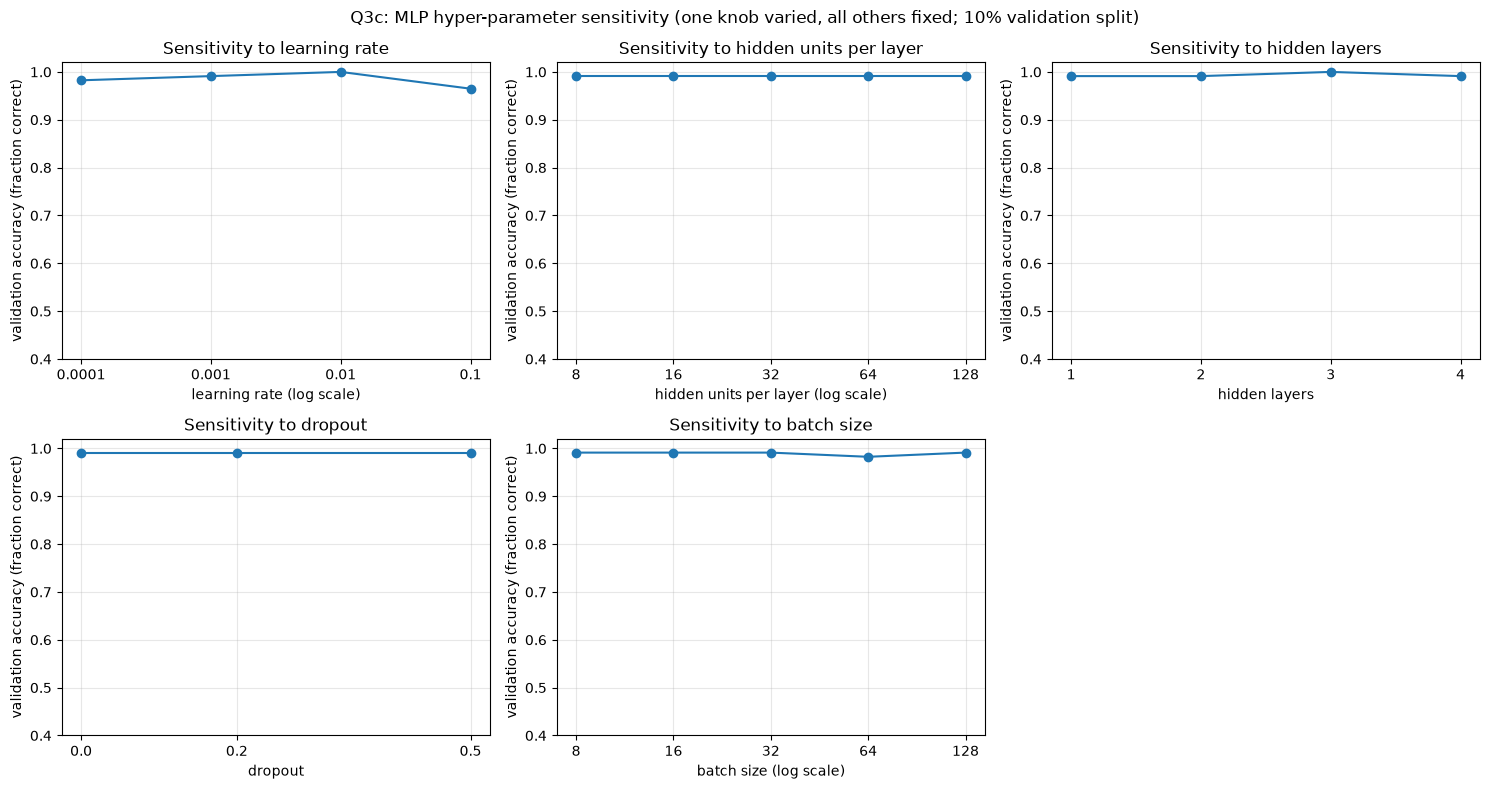

In [7]:
def build_mlp(n_features, n_layers=2, hidden_dim=32, activation=nn.ReLU, dropout=0.0):
    """A configurable MLP, so a sweep can vary one structural knob at a time."""
    layers = []
    in_dim = n_features
    for _ in range(n_layers):
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(activation())
        if dropout:
            layers.append(nn.Dropout(dropout))
        in_dim = hidden_dim
    layers.append(nn.Linear(in_dim, 2))
    return nn.Sequential(*layers)


BASE_CONFIG = dict(n_layers=2, hidden_dim=32, activation=nn.ReLU, dropout=0.0,
                   lr=MLP_LR, epochs=MLP_EPOCHS, batch_size=MLP_BATCH)


SWEEPS = {
    'learning rate': ('lr', [0.0001, 0.001, 0.01, 0.1]),
    'hidden units per layer': ('hidden_dim', [8, 16, 32, 64, 128]),
    'hidden layers': ('n_layers', [1, 2, 3, 4]),
    'dropout': ('dropout', [0.0, 0.2, 0.5]),
    'batch size': ('batch_size', [8, 16, 32, 64, 128]),
}


def sensitivity_analysis(X_train, y_train, sweeps=SWEEPS):
    """Q3c: vary one hyper-parameter at a time, holding the rest at BASE_CONFIG.

    Two decisions worth stating. (1) One knob at a time -- a full cross-product would
    confound the effects and no single hyper-parameter's influence could be read off it.
    (2) Scored on a 10% validation split carved out of the *training* set, never on test:
    picking hyper-parameters by test accuracy turns the reported test number into a
    best-of-N and it stops being an estimate of generalization.
    """
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.1, random_state=SEED, stratify=y_train
    )
    X_tr_t, y_tr_t, X_val_t, y_val_t = to_tensors(X_tr, X_val, y_tr, y_val)
    n_features = X_tr_t.shape[1]

    results, diagnostics = {}, {}
    for label, (param, values) in sweeps.items():
        for value in values:
            cfg = dict(BASE_CONFIG, **{param: value})
            set_seed()  # identical init across the sweep: differences are the knob, not luck
            model = build_mlp(n_features, cfg['n_layers'], cfg['hidden_dim'],
                              cfg['activation'], cfg['dropout'])
            losses = train_torch(model, X_tr_t, y_tr_t, lr=cfg['lr'], epochs=cfg['epochs'],
                                 batch_size=cfg['batch_size'])
            results[(label, value)] = evaluate_torch(model, X_val_t, y_val_t)
            # Evidence that the configurations really differ, and that the flat validation
            # curves are saturation rather than noise: parameter count, how far training
            # actually got, and *which* validation neurons each run gets wrong.
            model.eval()
            with torch.no_grad():
                wrong = (model(X_val_t).argmax(dim=1) != y_val_t).nonzero().flatten()
            diagnostics[(label, value)] = {
                'params': sum(p.numel() for p in model.parameters()),
                'final_train_loss': losses[-1],
                'train_accuracy': evaluate_torch(model, X_tr_t, y_tr_t)[0],
                'wrong': wrong.tolist(),
            }
    return results, diagnostics


def report_sensitivity(results, diagnostics=None, sweeps=SWEEPS):
    """Q3c: print the sweep as a table and plot validation accuracy against each knob.

    With `diagnostics` from sensitivity_analysis it also prints the evidence behind the
    reading of those curves: that the models genuinely differ, and that the flat
    validation accuracy is one stubborn neuron rather than random variation.
    """
    for label, (_, values) in sweeps.items():
        print(f'{label}')
        print(f"  {'value':>8s} {'accuracy':>9s} {'precision':>10s} {'recall':>8s} {'f1':>8s}")
        for value in values:
            acc, prec, rec, f1 = results[(label, value)]
            print(f'  {value:>8} {acc:9.4f} {prec:10.4f} {rec:8.4f} {f1:8.4f}')
        best = max(values, key=lambda v: results[(label, v)][0])
        print(f'  -> best {label}: {best} '
              f'(validation accuracy {results[(label, best)][0]:.4f})\n')

    if diagnostics is not None:
        print('Diagnostics: do the configurations actually differ?')
        print(f"  {'configuration':34s} {'params':>8s} {'train loss':>11s} "
              f"{'train acc':>10s} {'val errors':>11s}")
        for label, (_, values) in sweeps.items():
            for value in values:
                d = diagnostics[(label, value)]
                print(f'  {label + " = " + str(value):34s} {d["params"]:8d} '
                      f'{d["final_train_loss"]:11.5f} {d["train_accuracy"]:10.4f} '
                      f'{len(d["wrong"]):11d}')

        # Which validation neurons are responsible for the flat curves?
        tally = {}
        for d in diagnostics.values():
            for i in d['wrong']:
                tally[i] = tally.get(i, 0) + 1
        n_runs = len(diagnostics)
        print(f'\n  validation neurons misclassified, across all {n_runs} runs:')
        for i, count in sorted(tally.items(), key=lambda kv: kv[1], reverse=True)[:5]:
            print(f'    validation index {i:4d}: wrong in {count:2d} / {n_runs} runs')
        print()

    # 2x3 grid rather than one row: five panels side by side are unreadable once the
    # figure is shrunk to page width in the report.
    n_cols = 3
    n_rows = -(-len(sweeps) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    for ax in axes[len(sweeps):]:
        ax.set_visible(False)
    for ax, (label, (_, values)) in zip(axes, sweeps.items()):
        accuracies = [results[(label, v)][0] for v in values]
        ax.plot(values, accuracies, marker='o')
        ax.set_title(f'Sensitivity to {label}')
        # Learning rate, batch size and width are swept over powers of 10 / 2, so a log
        # axis spaces them evenly; the rest are small integers or fractions.
        log_x = label in ('learning rate', 'batch size', 'hidden units per layer')
        ax.set_xlabel(label + (' (log scale)' if log_x else ''))
        ax.set_ylabel('validation accuracy (fraction correct)')
        ax.set_ylim(0.4, 1.02)
        ax.grid(alpha=0.3)
        if log_x:
            ax.set_xscale('log')
            ax.minorticks_off()
        # Tick only the values actually tested, so no axis shows e.g. "2.5 hidden layers".
        ax.set_xticks(values)
        ax.set_xticklabels([str(v) for v in values])
    fig.suptitle('Q3c: MLP hyper-parameter sensitivity '
                 '(one knob varied, all others fixed; 10% validation split)')
    plt.tight_layout()
    plt.show()


sensitivity, sensitivity_diag = sensitivity_analysis(X_train, y_train)
report_sensitivity(sensitivity, sensitivity_diag)

### Findings — 3c

**Only the learning rate has a large effect.** The other four sweeps barely move:

* **hidden units per layer** (8 to 128) and **dropout** (0, 0.2, 0.5) are completely
  flat — 0.9912 at every value;
* **hidden layers** and **batch size** each differ at a single setting, by one sample:
  3 hidden layers reaches 1.0000 (one more correct), batch size 64 drops to 0.9825 (one
  more wrong).

With 114 validation samples one sample is 0.0088 accuracy, so none of those four sweeps
shows a difference larger than a single neuron.

**The diagnostics table above explains the flatness.** Two things it shows:

1. **The configurations really are different models.** The parameter count ranges from
   426 (8 hidden units) to 22,146 (128), and the final training loss from 0.00001 to
   0.00816 across that same sweep. The sweep is doing its job.
2. **One neuron is responsible.** Across all 21 runs, **validation index 105 is
   misclassified in 18 of them**, and no other neuron is wrong in more than one run. In
   most configurations it is the *only* error, which is why so many rows read exactly
   0.9912 = 113/114.

So this is **saturation, not noise**: nearly every configuration reaches 1.0000 training
accuracy, and the validation set holds one hard example that almost nothing gets right.
There is no headroom left for a hyper-parameter to move the score.

The one hyper-parameter with a real effect is the learning rate:

| learning rate | validation accuracy | training accuracy | final train loss |
|---|---|---|---|
| 0.0001 | 0.9825 | 0.9873 | 0.05252 |
| 0.001 | 0.9912 | 1.0000 | 0.00010 |
| 0.01 | 1.0000 | 1.0000 | 0.00000 |
| **0.1** | **0.5088** | **0.5083** | **0.68036** |

At lr = 0.0001 the network has not finished converging in 100 epochs — its training loss
is still 0.05, orders of magnitude above the others. At **lr = 0.1 optimization breaks
down entirely**: the training loss sits at 0.68036, essentially ln 2 ≈ 0.693, which is
the loss of a classifier that answers 50/50 on every sample. Training accuracy is 0.5083,
the network puts **all 114** validation neurons in one class (56 validation errors in the
diagnostics table), and so precision, recall and F1 are all 0.0000 while the accuracy of
0.5088 is exactly the share of aspiny neurons in the validation set.

The conclusion is not that architecture "doesn't matter" in general. This task is nearly
linearly separable, so every reasonable architecture saturates, and the only
hyper-parameter that can hurt is the one that breaks optimization itself.

*(The sklearn `UndefinedMetricWarning` above comes from the lr=0.1 run predicting zero
spiny samples, which leaves precision undefined. It is a symptom of the collapse, not a
bug.)*

## Question 4 — Training the MLP with Gradient Descent

We train a network with one hidden layer (32 units, ReLU) using **full-batch Gradient
Descent** — one parameter update per epoch over the entire training set — and plot the
loss for the training set and for a validation set of 10% of the training data.

Section 4b requires a second run with **SGD at batch size 10**; both models are trained
here together so the loss curves can be shown side by side on the same axes. They get
the same split, the same weight initialization (same seed), the same optimizer (plain
SGD, not Adam) and the same learning rate — so the only difference between them is the
batch size.

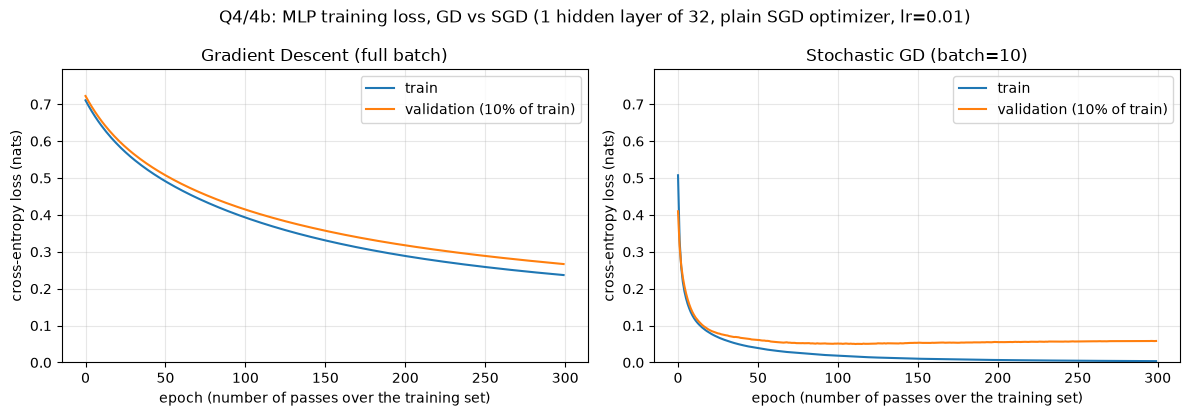

In [8]:
GD_LR = 0.01
GD_EPOCHS = 300
SGD_BATCH = 10
INV_LABELS = {v: k for k, v in LABELS.items()}


def to_label_names(indices):
    """Torch class indices -> the original string labels, so report_errors can be reused."""
    return np.array([INV_LABELS[int(i)] for i in indices])


def train_with_curves(model, X_tr, y_tr, X_val, y_val, lr=GD_LR, epochs=GD_EPOCHS,
                      batch_size=None):
    """Train and record the per-epoch train and validation loss.

    batch_size=None is full-batch Gradient Descent: one parameter update per epoch over
    the whole training set. Any integer is mini-batch SGD with that batch size. The train
    loss is the batch-size-weighted mean over the epoch, so the two regimes are comparable
    on the same axes; validation loss is always a single full-set forward pass in eval
    mode (dropout off, no gradients).
    """
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    n_train = X_tr.shape[0]
    step = n_train if batch_size is None else batch_size

    train_losses, val_losses = [], []
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(n_train) if batch_size else torch.arange(n_train)
        epoch_loss = 0.0
        for begin in range(0, n_train, step):
            idx = perm[begin:begin + step]
            optimizer.zero_grad()
            loss = criterion(model(X_tr[idx]), y_tr[idx])
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(idx)
        train_losses.append(epoch_loss / n_train)

        model.eval()
        with torch.no_grad():
            val_losses.append(criterion(model(X_val), y_val).item())
    return train_losses, val_losses


def q4_tensors(X_train, y_train, X_test, y_test):
    """The data split shared by every Q4 run: 90/10 train/validation out of the training
    set, plus the test set.

    All three are standardized with ONE scaler fitted on the 90% training part only. This
    matters: the models train on the 90% part, so the test set has to be transformed with
    that same scaler. Fitting a separate scaler on the full training set would feed the
    models test features on a slightly different scale than the ones they trained on.
    """
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.1, random_state=SEED, stratify=y_train
    )
    scaler = StandardScaler().fit(X_tr)
    features = lambda X: torch.tensor(scaler.transform(X), dtype=torch.float32)
    labels = lambda y: torch.tensor(y.map(LABELS).values, dtype=torch.long)
    return (features(X_tr), labels(y_tr), features(X_val), labels(y_val),
            features(X_test), labels(y_test))


def train_mlp_with_GD(X_tr_t, y_tr_t, X_val_t, y_val_t, batch_size=None, dropout=0.0,
                      hidden_dim=32, lr=GD_LR, epochs=GD_EPOCHS):
    """Q4: one hidden layer trained by GD (batch_size=None) or SGD, on pre-scaled tensors.

    Takes tensors rather than frames so every Q4 run shares one split and one scaler.
    Returns the fitted model and the two loss curves.
    """
    set_seed()
    # With n_layers=1 the dropout sits between the hidden layer and the output layer,
    # i.e. immediately before the classification layer, which is what Q4d asks for.
    model = build_mlp(X_tr_t.shape[1], n_layers=1, hidden_dim=hidden_dim, dropout=dropout)
    curves = train_with_curves(model, X_tr_t, y_tr_t, X_val_t, y_val_t,
                               lr=lr, epochs=epochs, batch_size=batch_size)
    return model, curves


def plot_loss_curves(runs, title):
    """Q4/4b: train vs validation cross-entropy against epoch, one panel per run."""
    fig, axes = plt.subplots(1, len(runs), figsize=(6 * len(runs), 4.2), squeeze=False)
    y_max = max(max(max(tr), max(vl)) for _, tr, vl in runs) * 1.1
    for ax, (name, train_losses, val_losses) in zip(axes[0], runs):
        ax.plot(train_losses, label='train')
        ax.plot(val_losses, label='validation (10% of train)')
        ax.set_title(name)
        ax.set_xlabel('epoch (number of passes over the training set)')
        ax.set_ylabel('cross-entropy loss (nats)')
        ax.set_ylim(0, y_max)
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


X_tr_t, y_tr_t, X_val_t, y_val_t, X_test_t, y_test_t = q4_tensors(
    X_train, y_train, X_test, y_test
)

gd_model, (gd_train, gd_val) = train_mlp_with_GD(X_tr_t, y_tr_t, X_val_t, y_val_t)
sgd_model, (sgd_train, sgd_val) = train_mlp_with_GD(X_tr_t, y_tr_t, X_val_t, y_val_t,
                                                    batch_size=SGD_BATCH)

plot_loss_curves([('Gradient Descent (full batch)', gd_train, gd_val),
                  (f'Stochastic GD (batch={SGD_BATCH})', sgd_train, sgd_val)],
                 'Q4/4b: MLP training loss, GD vs SGD '
                 f'(1 hidden layer of 32, plain SGD optimizer, lr={GD_LR})')

### 4a — Error analysis of the GD-trained model

MLP trained with GD: accuracy=0.9333, precision=0.8954, recall=0.9786, f1=0.9352
  true negatives  (aspiny -> aspiny): 129
  false positives (aspiny -> spiny) : 16
  false negatives (spiny  -> aspiny): 3
  true positives  (spiny  -> spiny) : 137


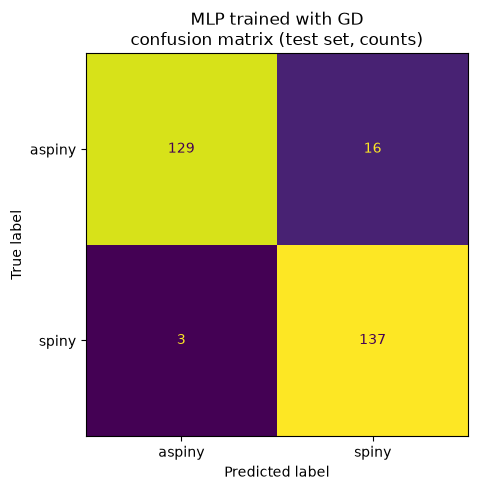

(0.9333333333333333,
 0.8954248366013072,
 0.9785714285714285,
 0.9351535836177475)

In [9]:
gd_model.eval()
with torch.no_grad():
    gd_pred = gd_model(X_test_t).argmax(dim=1)

report_errors(y_test, to_label_names(gd_pred), 'MLP trained with GD')

### Findings — 4a

The GD-trained model reaches only 0.9333 accuracy — well below every model in Questions
1–3, including the logistic regression. Its errors break down as:

* **16 false positives** (aspiny classified as spiny)
* **3 false negatives** (spiny classified as aspiny)

so precision (0.8954) is far below recall (0.9786) — the opposite behavior to the
logistic regression in 1a.

**This is not a bug; it is a consequence of the optimization method.** Full-batch GD
performs **exactly one parameter update per epoch**, so 300 epochs means 300 updates
in total. By comparison, SGD with batch size 10 performs about 103 updates per epoch,
i.e. roughly 30,900 updates over the same number of epochs. The GD-trained network
simply has not finished converging — visible in the plot above, where its loss is still
descending at the end of training.

### 4b — Comparing the GD and SGD loss curves

Both curves are plotted above. Below are the final loss values. The gap is reported as
validation minus train, so a positive value always means "worse on held-out data",
consistent with the metric tables elsewhere in this notebook.

GD (full batch):
  train loss      0.7105 -> 0.2370   (last 50 epochs: -0.0223)
  validation loss 0.7223 -> 0.2668   (final gap +0.0298)
  lowest validation loss 0.2668 at epoch 300 of 300
  train loss first below 0.1: never reached
SGD (batch=10):
  train loss      0.5074 -> 0.0037   (last 50 epochs: -0.0012)
  validation loss 0.4098 -> 0.0583   (final gap +0.0546)
  lowest validation loss 0.0501 at epoch 112 of 300
  train loss first below 0.1: epoch 15

MLP trained with SGD (batch=10): accuracy=0.9860, precision=0.9857, recall=0.9857, f1=0.9857
  true negatives  (aspiny -> aspiny): 143
  false positives (aspiny -> spiny) : 2
  false negatives (spiny  -> aspiny): 2
  true positives  (spiny  -> spiny) : 138


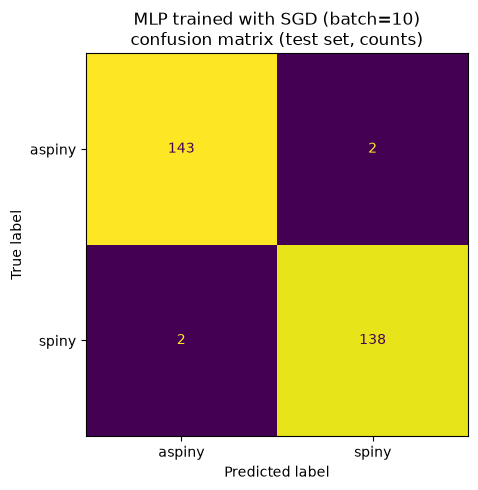

(0.9859649122807017,
 0.9857142857142858,
 0.9857142857142858,
 0.9857142857142858)

In [10]:
def describe_curve(name, train_losses, val_losses, threshold=0.1, tail=50):
    """Q4b/4c/4d: the numbers behind the loss curves, which a plot can only suggest.

    Prints where training got to, the lowest validation loss and the epoch it occurred
    (the point after which further training only overfits), whether the training loss is
    still falling at the end, and how many epochs it took to get below `threshold`.
    """
    best = min(range(len(val_losses)), key=lambda i: val_losses[i])
    below = next((i + 1 for i, v in enumerate(train_losses) if v < threshold), None)
    tail_change = train_losses[-1] - train_losses[-1 - tail]
    print(f'{name}:')
    print(f'  train loss      {train_losses[0]:.4f} -> {train_losses[-1]:.4f}'
          f'   (last {tail} epochs: {tail_change:+.4f})')
    print(f'  validation loss {val_losses[0]:.4f} -> {val_losses[-1]:.4f}'
          f'   (final gap {val_losses[-1] - train_losses[-1]:+.4f})')
    print(f'  lowest validation loss {val_losses[best]:.4f} at epoch {best + 1} '
          f'of {len(val_losses)}')
    print(f'  train loss first below {threshold}: '
          f'{"epoch " + str(below) if below else "never reached"}')


describe_curve('GD (full batch)', gd_train, gd_val)
describe_curve(f'SGD (batch={SGD_BATCH})', sgd_train, sgd_val)

# 4b repeats 4a with SGD: confusion matrix, precision and recall on the same test set.
print()
sgd_model.eval()
with torch.no_grad():
    sgd_pred = sgd_model(X_test_t).argmax(dim=1)

report_errors(y_test, to_label_names(sgd_pred), f'MLP trained with SGD (batch={SGD_BATCH})')

### Findings — 4b

| method | parameter updates | train loss | validation loss |
|---|---|---|---|
| GD (full batch) | 300 | 0.2370 | 0.2668 |
| SGD (batch=10) | 30,900 | 0.0037 | 0.0583 |

**SGD converges far faster per epoch.** At the same learning rate and the same 300
epochs it reaches a training loss about 60× lower. Each SGD step is *less* accurate than
a GD step — it estimates the gradient from 10 samples instead of all 1,025 — but SGD
takes 103 steps per epoch against GD's one.

The printout above quantifies the difference:

* **GD** goes from 0.7105 to 0.2370 and is **still falling at the end** (the last 50
  epochs still take off 0.0223). It never gets below 0.1 at all within 300 epochs.
* **SGD** is below 0.1 by **epoch 15** and ends at 0.0037.

Both curves look smooth in the plot, which needs a word of explanation for SGD. The
noise of individual mini-batch steps is real, but each plotted point is the *average*
over all 103 mini-batches in that epoch, which smooths it away. The visibly noisy curve
in 4d comes from dropout, not from the batch size.

The two runs also differ in shape late in training. GD's lowest validation loss is at
**epoch 300** — the very last one — so it is still improving when training stops. SGD's
lowest is at **epoch 112**, after which validation loss rises while training loss keeps
falling toward zero. That is the signature of overfitting, analyzed in 4c.

### 4c — Does the MLP overfit?

In [11]:
q4_results = {}
for name, model in [('mlp_gd', gd_model), ('mlp_sgd', sgd_model)]:
    q4_results[(name, 'train')] = evaluate_torch(model, X_tr_t, y_tr_t)
    q4_results[(name, 'test')] = evaluate_torch(model, X_test_t, y_test_t)

report_overfitting(q4_results, ['mlp_gd', 'mlp_sgd'])

model        metric        train     test      gap
--------------------------------------------------
mlp_gd       accuracy     0.9200   0.9333  -0.0133
mlp_gd       precision    0.9089   0.8954  +0.0135
mlp_gd       recall       0.9306   0.9786  -0.0480
mlp_gd       f1           0.9196   0.9352  -0.0155
mlp_sgd      accuracy     1.0000   0.9860  +0.0140
mlp_sgd      precision    1.0000   0.9857  +0.0143
mlp_sgd      recall       1.0000   0.9857  +0.0143
mlp_sgd      f1           1.0000   0.9857  +0.0143


### Findings — 4c

The two models land on opposite sides:

| model | train accuracy | test accuracy | gap | diagnosis |
|---|---|---|---|---|
| `mlp_gd` | 0.9200 | 0.9333 | **-0.0133** | **underfitting** |
| `mlp_sgd` | 1.0000 | 0.9860 | **+0.0140** | **overfitting** |

**The GD-trained model underfits.** It scores *higher* on test than on train. Its train
and validation losses are both high (0.2370 and 0.2668), stay close together, and are
still falling at the last epoch — its best validation loss is at epoch 300, so it never
turned the corner into overfitting. A model that has not yet fit its own training set
cannot be memorizing it.

**The SGD-trained model overfits**, and the curve shows exactly when it starts. Its
validation loss bottoms out at **0.0501 at epoch 112** and then rises to 0.0583 by epoch
300, while the training loss keeps falling to 0.0037 — by the end, validation loss is
about 16× the training loss. Every epoch after 112 improves the fit to the training data
and makes the model slightly worse on unseen data. The test metrics agree: 1.0000
accuracy on train against 0.9860 on test.

The overfitting is real but mild: the accuracy gap of +0.0140 is 4 neurons out of 285,
and the model still generalizes well. Stopping at around epoch 112 (early stopping on
the validation loss) would have avoided most of it.

### 4d — Adding 50% dropout before the classification layer

The dropout sits between the hidden layer and the output layer, i.e. immediately before
the classification layer. Training uses SGD (batch=10) so the comparison is against
`mlp_sgd` — the one model of the two that actually overfitted, and therefore the only
one dropout has anything to improve.

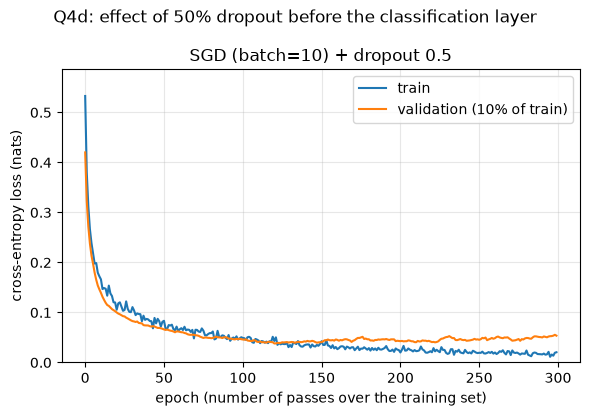

model        metric        train     test      gap
--------------------------------------------------
mlp_sgd      accuracy     1.0000   0.9860  +0.0140
mlp_sgd      precision    1.0000   0.9857  +0.0143
mlp_sgd      recall       1.0000   0.9857  +0.0143
mlp_sgd      f1           1.0000   0.9857  +0.0143
mlp_dropout50 accuracy     0.9990   0.9930  +0.0060
mlp_dropout50 precision    0.9980   0.9929  +0.0052
mlp_dropout50 recall       1.0000   0.9929  +0.0071
mlp_dropout50 f1           0.9990   0.9929  +0.0062

SGD (batch=10) + dropout 0.5:
  train loss      0.5329 -> 0.0204   (last 50 epochs: +0.0016)
  validation loss 0.4201 -> 0.0537   (final gap +0.0332)
  lowest validation loss 0.0381 at epoch 121 of 300
  train loss first below 0.1: epoch 33


In [12]:
drop_model, (drop_train, drop_val) = train_mlp_with_GD(
    X_tr_t, y_tr_t, X_val_t, y_val_t, batch_size=SGD_BATCH, dropout=0.5
)
plot_loss_curves([(f'SGD (batch={SGD_BATCH}) + dropout 0.5', drop_train, drop_val)],
                 'Q4d: effect of 50% dropout before the classification layer')

q4_results[('mlp_dropout50', 'train')] = evaluate_torch(drop_model, X_tr_t, y_tr_t)
q4_results[('mlp_dropout50', 'test')] = evaluate_torch(drop_model, X_test_t, y_test_t)
report_overfitting(q4_results, ['mlp_sgd', 'mlp_dropout50'])
print()
describe_curve(f'SGD (batch={SGD_BATCH}) + dropout 0.5', drop_train, drop_val)

### Findings — 4d

**Yes, dropout improved generalization.**

| model | train accuracy | test accuracy | gap | min. validation loss |
|---|---|---|---|---|
| `mlp_sgd` (no dropout) | 1.0000 | 0.9860 | +0.0140 | 0.0501 (epoch 112) |
| `mlp_dropout50` | 0.9990 | **0.9930** | **+0.0060** | **0.0381** (epoch 121) |

The improvement shows on three measures:

1. **Test accuracy rose** from 0.9860 to 0.9930 — two more neurons classified correctly.
2. **The train–test accuracy gap shrank by more than half**, from +0.0140 to +0.0060.
   Training accuracy is no longer a perfect 1.0000: the network stopped memorizing the
   training set completely.
3. **The best validation loss is 24% lower** (0.0381 against 0.0501).

One caution about reading the loss plot. The training loss is recorded **with dropout
switched on**, while the validation loss is computed with dropout off. That is why the
training curve is noisy (each step drops a different random half of the hidden units)
and why it sits *above* the validation curve for the first ~120 epochs. The raw loss
values are therefore not a like-for-like comparison, and the accuracy gap above — where
both sets are evaluated with dropout off — is the fair measure.

Dropout reduced overfitting but did not remove it: after epoch 121 the validation loss
rises again (to 0.0537), just more slowly than without dropout.

The mechanism: on every training step dropout zeroes a random half of the hidden units,
so the output layer cannot depend on any particular unit or combination of units. The
network has to spread the information across many units, which makes the learned
function more robust to the small differences between training and test neurons.

### 4e — Error analysis: which neurons does the MLP get wrong?

For each misclassified test neuron we look at two things:

1. **Does it resemble the other class?** We rank the features by how well they separate
   spiny from aspiny in the training set (Cohen's d), take the top 10, and count how many
   of them put the neuron closer to the *other* class's mean than to its own. The same
   count over all correctly classified neurons is the baseline.
2. **Is it unusual for its own class?** The three features on which it deviates most from
   its own class's mean, in training-set standard deviations (z-scores), with the
   deviation from the other class's mean alongside.

In [13]:
def error_analysis(model, X_train, y_train, X_test, y_test, X_test_t, y_test_t,
                   n_show=5, n_separating=10):
    """Q4e: which test neurons the MLP gets wrong, and whether they resemble the other class.

    Two views of each mistake:
    1. The features on which it deviates most from its own class's training mean, in
       training standard deviations -- is this neuron atypical for its class?
    2. On the `n_separating` features that best separate the classes in the training set
       (largest |Cohen's d|), how many put it closer to the *other* class's mean? The same
       count over the correctly classified neurons is the baseline to compare against.
    """
    model.eval()
    with torch.no_grad():
        p_spiny = torch.softmax(model(X_test_t), dim=1)[:, 1]
    predicted = (p_spiny > 0.5).long()
    wrong = (predicted != y_test_t).nonzero().flatten().tolist()
    print(f'{len(wrong)} misclassified out of {len(y_test_t)}')

    means = {label: X_train[y_train == label].mean() for label in LABELS}
    variances = {label: X_train[y_train == label].var() for label in LABELS}
    stds = X_train.std()
    cohens_d = ((means['spiny'] - means['aspiny'])
                / np.sqrt((variances['spiny'] + variances['aspiny']) / 2)).abs()
    ranked_features = cohens_d.sort_values(ascending=False).index
    separating = ranked_features[:n_separating]
    # Rank of each feature by class separation, so "unusual on this feature" can be read
    # against "does this feature distinguish the classes at all".
    rank = {f: i + 1 for i, f in enumerate(ranked_features)}

    def closer_to_other(i):
        row, true_label = X_test.iloc[i], y_test.iloc[i]
        other = [label for label in LABELS if label != true_label][0]
        return sum(abs(row[f] - means[other][f]) < abs(row[f] - means[true_label][f])
                   for f in separating)

    for i in wrong[:n_show]:
        row = X_test.iloc[i]
        true_label = y_test.iloc[i]
        other = [label for label in LABELS if label != true_label][0]
        z_true = (row - means[true_label]) / stds
        z_other = (row - means[other]) / stds
        top = z_true.abs().sort_values(ascending=False).head(3)
        print(f'\n  test index {i}: true={true_label}, predicted={INV_LABELS[int(predicted[i])]}, '
              f'P(spiny)={p_spiny[i]:.3f}')
        print(f'    closer to {other} on {closer_to_other(i)}/{n_separating} '
              f'most class-separating features')
        for feature in top.index:
            closer = 'other' if abs(z_other[feature]) < abs(z_true[feature]) else 'own'
            print(f'    {feature:34s} value={row[feature]:10.3f} '
                  f'z vs {true_label:6s}={z_true[feature]:+6.2f} '
                  f'z vs {other:6s}={z_other[feature]:+6.2f}  -> closer to {closer}  '
                  f'(|d|={cohens_d[feature]:.2f}, separation rank '
                  f'{rank[feature]}/{len(ranked_features)})')

    right = [i for i in range(len(y_test_t)) if i not in wrong]
    counts = [closer_to_other(i) for i in right]
    print(f'\n  baseline, {len(right)} correctly classified neurons: closer to the other class '
          f'on a median of {np.median(counts):.0f}/{n_separating} '
          f'(mean {np.mean(counts):.2f}) most class-separating features')
    print(f'  most class-separating features: {", ".join(separating)}')
    return wrong


wrong = error_analysis(sgd_model, X_train, y_train, X_test, y_test,
                       X_test_t, y_test_t)

4 misclassified out of 285

  test index 176: true=spiny, predicted=aspiny, P(spiny)=0.174
    closer to aspiny on 5/10 most class-separating features
    input_resistance_mohm              value=   406.757 z vs spiny = +2.21 z vs aspiny= +1.64  -> closer to other  (|d|=0.60, separation rank 20/41)
    upstroke_v                         value=   -16.305 z vs spiny = -2.17 z vs aspiny= -1.35  -> closer to other  (|d|=0.89, separation rank 18/41)
    threshold_v                        value=   -45.085 z vs spiny = -1.85 z vs aspiny= -1.83  -> closer to other  (|d|=0.02, separation rank 39/41)

  test index 187: true=aspiny, predicted=spiny, P(spiny)=0.632
    closer to spiny on 4/10 most class-separating features
    input_resistance_mohm              value=   419.959 z vs aspiny= +1.77 z vs spiny = +2.34  -> closer to own  (|d|=0.60, separation rank 20/41)
    threshold_v_long_square            value=   -31.000 z vs aspiny= +1.66 z vs spiny = +1.39  -> closer to other  (|d|=0.28, separa

### Findings — 4e

The network misclassifies **4 of 285** test neurons. Two checks show these are not
random mistakes: they are neurons that genuinely resemble the other class.

**Check 1 — they resemble the other class on the features that matter most.** We ranked
all 41 features by how well they separate spiny from aspiny in the training set
(Cohen's d); the top 10 are all action-potential shape features, such as the
upstroke/downstroke ratio, downstroke velocity and peak voltage. On those 10 features:

| test index | true class | P(spiny) | closer to the *other* class on |
|---|---|---|---|
| 176 | spiny  | 0.174 | 5 / 10 features |
| 187 | aspiny | 0.632 | 4 / 10 features |
| 245 | spiny  | 0.432 | 4 / 10 features |
| 257 | aspiny | 0.925 | **7 / 10** features |
| *281 correctly classified* | | | *median 1 / 10* |

A correctly classified neuron is closer to the other class on a median of **1** of these
features. Every misclassified neuron is on **4 to 7**. On the features the model relies
on, these neurons look like the class it assigned them to.

**Check 2 — they are unusual for their own class.** Each error also sits far from its own
class mean on some feature; the most extreme is index 257, whose `sag` is **3.72 standard
deviations** above the aspiny mean. But being an outlier is not in itself an explanation,
and the separation ranks printed above show why: `sag` ranks 30th of 41 features
(|d| = 0.28) and `threshold_v` 39th (|d| = 0.02), so a neuron can be extreme on them
without looking like the other class at all. Only index 245 is most unusual on strongly
separating features (`fast_trough_v_long_square`, rank 6, and `fast_trough_v`, rank 14).
Check 1 is what explains the errors; check 2 shows these are unusual cells.

The model's confidence varies. Indices 187 (P=0.632) and 245 (P=0.432) sit close to the
0.5 boundary — borderline cases. Indices 176 (P=0.174) and 257 (P=0.925) are
**confidently wrong**: for these the electrical features point firmly to the other class,
and 257 matches spiny on 7 of the 10 most informative features.

**Conclusion:** the errors reflect a real overlap between the two cell types in this
feature space. A small number of neurons carry the electrical signature of the other
type, and no classifier using these features alone could be expected to get them right.
Possible causes include natural biological variation or errors in the dendrite-type
labels.